In [1]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision import transforms
from diffusers import StableDiffusionPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model
from transformers import CLIPTextModel, CLIPTokenizer
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
DATASET_DIR = "../classifier/emoart-gan-train/final-images"
OUTPUT_DIR = "lora_art_model"
LORA_DIR = "lora_art_model_detenido"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
EPOCHS = 30
VALIDATION_PROMPT = "imprsn style, an oil painting of a landscape with trees and a river at sunset"

In [4]:
print("Cargando componentes de Stable Diffusion...")
# Tokenizador y Codificador de Texto (CLIP) -> Congelados
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder").to(DEVICE)
text_encoder.requires_grad_(False)

# VAE (Autoencoder Variacional) -> Congelado (Comprime la imagen)
pipeline = StableDiffusionPipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
vae = pipeline.vae.to(DEVICE)
vae.requires_grad_(False)

# UNet (El motor que quita el ruido)
unet = pipeline.unet.to(DEVICE)
unet.requires_grad_(False) # Congelamos el UNet original

# Planificador de ruido
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

# LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"], # Inyectar en capas de atención
    lora_dropout=0.05,
    bias="none"
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, unet.parameters()), lr=LEARNING_RATE)

Cargando componentes de Stable Diffusion...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/home/mamp/Documents/semestre8/redes-neuronales-vision-computacion/proyecto/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696


In [5]:
dataset = load_dataset("imagefolder", data_dir=DATASET_DIR, split="train")

image_transforms = transforms.Compose([
    transforms.Resize((512, 512), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(512),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]), # Normalizar a [-1, 1] requerido por el VAE
])

def collate_fn(examples):
    # Procesar imágenes
    pixel_values = torch.stack([image_transforms(example["image"].convert("RGB")) for example in examples])

    # Procesar textos
    input_ids = tokenizer(
        [example["text"] for example in examples],
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).input_ids

    return {"pixel_values": pixel_values, "input_ids": input_ids}

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
print(f"Dataset cargado. Total de lotes por época: {len(dataloader)}")

Resolving data files:   0%|          | 0/242 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset cargado. Total de lotes por época: 241


Iniciando entrenamiento...


Epoch 1/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 5/30:   0%|          | 0/241 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Generando imagen de validación en la época 5...


  0%|          | 0/25 [00:00<?, ?it/s]

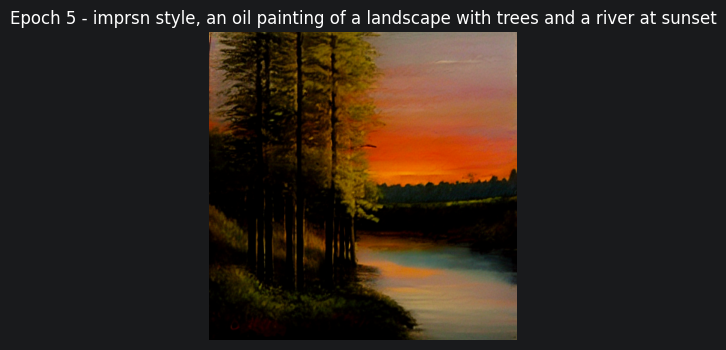

Epoch 6/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 7/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 8/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 9/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 10/30:   0%|          | 0/241 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Generando imagen de validación en la época 10...


  0%|          | 0/25 [00:00<?, ?it/s]

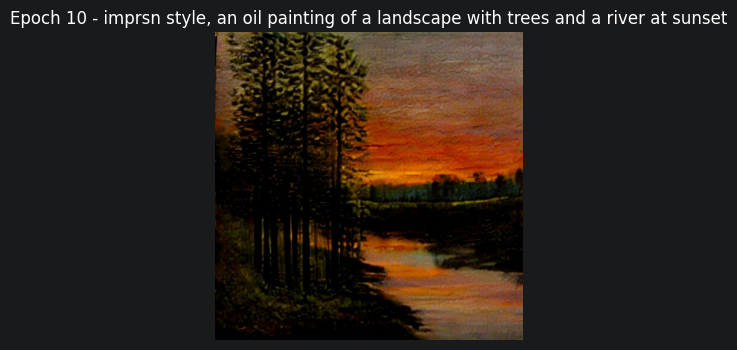

Epoch 11/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 12/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 13/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 14/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 15/30:   0%|          | 0/241 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Generando imagen de validación en la época 15...


  0%|          | 0/25 [00:00<?, ?it/s]

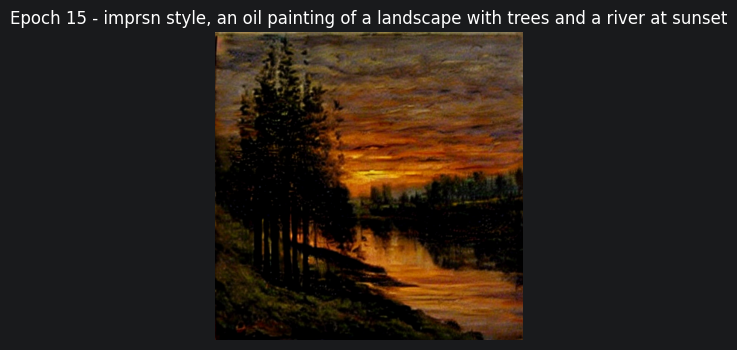

Epoch 16/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 17/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 18/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 19/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 20/30:   0%|          | 0/241 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Generando imagen de validación en la época 20...


  0%|          | 0/25 [00:00<?, ?it/s]

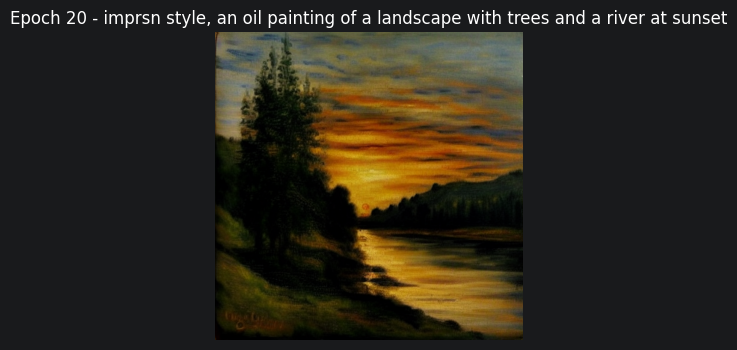

Epoch 21/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 22/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 23/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 24/30:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 25/30:   0%|          | 0/241 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Generando imagen de validación en la época 25...


  0%|          | 0/25 [00:00<?, ?it/s]

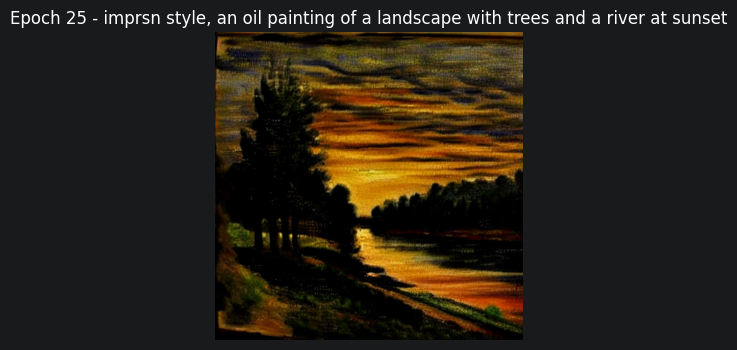

Epoch 26/30:   0%|          | 0/241 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
loss_history = []
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Iniciando entrenamiento...")
for epoch in range(EPOCHS):
    unet.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(progress_bar):
        pixel_values = batch["pixel_values"].to(DEVICE, dtype=torch.float16)
        input_ids = batch["input_ids"].to(DEVICE)

        # Comprimir imágenes al Espacio Latente usando el VAE
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor # Escalar latentes (regla de SD)

        # Generar ruido aleatorio para añadir a los latentes
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        # Elegir un paso de tiempo aleatorio para cada imagen (de 0 a 1000)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=DEVICE).long()

        # Añadir el ruido a los latentes (Proceso Forward)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Obtener las coordenadas matemáticas del texto (Prompt)
        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        # Predecir el ruido
        with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            # Calcular la pérdida
            loss = F.mse_loss(noise_pred, noise, reduction="mean")

        # Backpropagation solo para los pesos de LoRA
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"\nGenerando imagen de validación en la época {epoch+1}...")
        unet.eval()
        val_pipe = StableDiffusionPipeline(
            vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, unet=unet,
            scheduler=noise_scheduler, safety_checker=None, feature_extractor=None
        ).to(DEVICE)

        with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
            image = val_pipe(VALIDATION_PROMPT, num_inference_steps=25, generator=torch.manual_seed(42)).images[0]

        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.title(f"Epoch {epoch+1} - {VALIDATION_PROMPT}")
        plt.axis('off')
        plt.show()

unet.save_pretrained(OUTPUT_DIR)
print(f"Entrenamiento finalizado. Modelo LoRA guardado en: {OUTPUT_DIR}")

In [7]:
unet.save_pretrained("lora_art_model_detenido")
print("¡Salvado a tiempo!")

¡Salvado a tiempo!


In [9]:
print(loss_history)

[0.15613521345894923, 0.14284875067008884, 0.14310336811854446, 0.1572243255134131, 0.15232877651252688, 0.1767275519301937, 0.13075184387046673, 0.15434684447704572, 0.1361118571405759, 0.14953556946330004, 0.17574225392779994, 0.12999038089209727, 0.15329072490011833, 0.13531833738610302, 0.14847815249581856, 0.17464406737918614, 0.1291015579005804, 0.15203349531630123, 0.13440673597904765, 0.14727379686075467, 0.1733912200467947, 0.12812040075012462, 0.1506963089399264, 0.13343118542961824, 0.14599858445532743]


ValueError: x and y must have same first dimension, but have shapes (30,) and (25,)

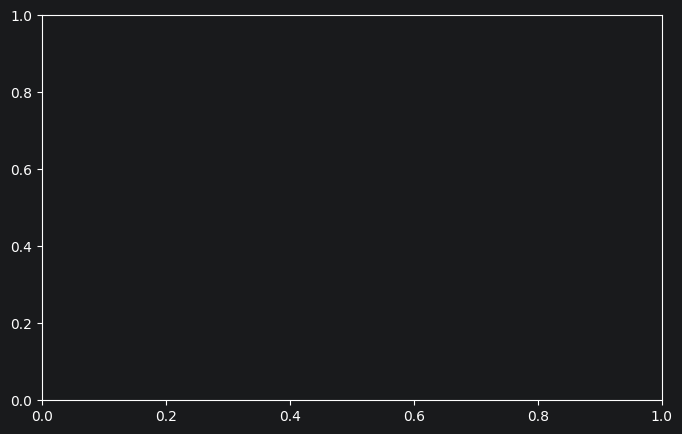

In [8]:
# Graficar la curva de aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', label='MSE Loss')
plt.title("Curva de Aprendizaje (Pérdida durante el entrenamiento LoRA)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.grid(True)
plt.legend()
plt.show()

Cargando pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/is

Cargando tus pesos LoRA...

Generando muestras de prueba...
Generando para la clase: cubism...


...

  0%|          | 0/30 [00:00<?, ?it/s]

Generando para la clase: color-field-painting...


  0%|          | 0/30 [00:00<?, ?it/s]

Generando para la clase: pop-art...


  0%|          | 0/30 [00:00<?, ?it/s]

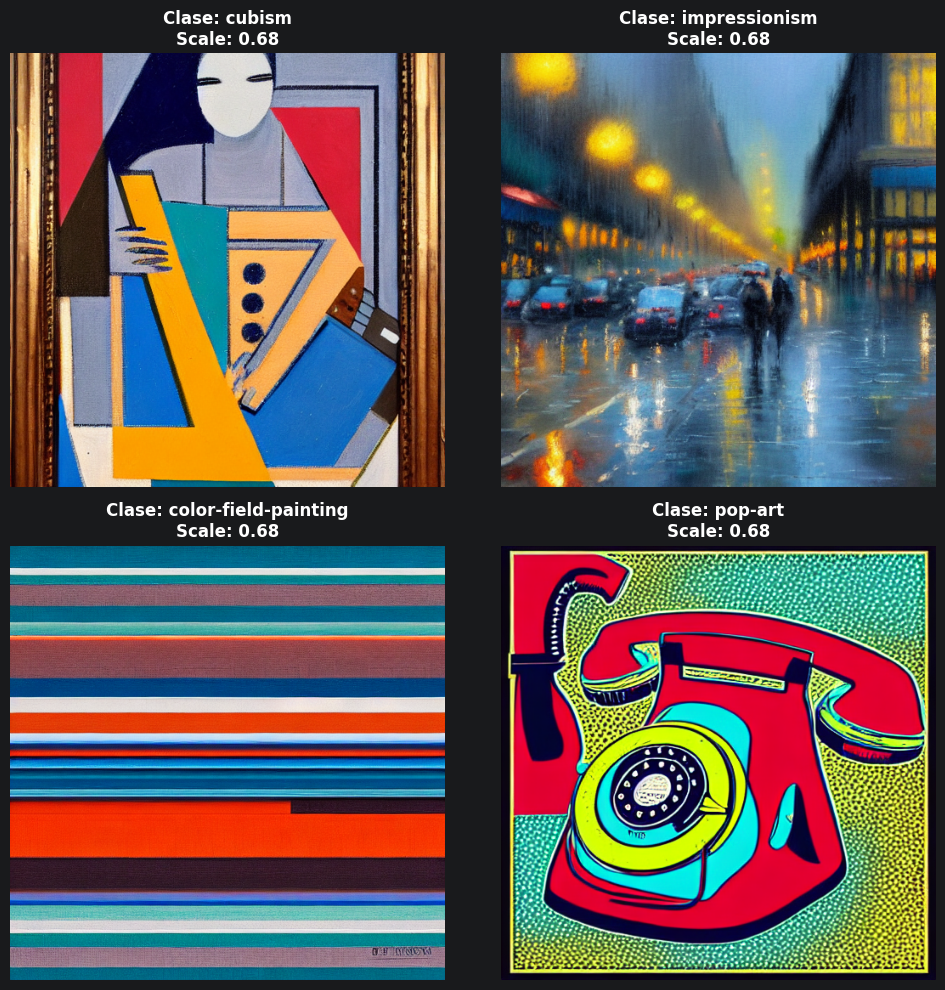

In [4]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

LORA_DIR = "lora_art_model_detenido"

print("Cargando pipeline...")
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    safety_checker=None
).to(DEVICE)

print("Cargando tus pesos LoRA...")
pipe.load_lora_weights(LORA_DIR)

PROMPTS_CLASES = {
    "cubism": "cbsm style, a oil painting of a woman playing a guitar, deconstructed geometric shapes, multiple perspectives, analytical cubism",
    "impressionism": "imprsn style, A pure impressionism painting of a bustling Paris boulevard on a rainy morning, reflections of soft pastel sky on the wet ground, hazy atmosphere, loose and rapid brushstrokes, focus on natural daylight and movement, fleeting moment",
    "color-field-painting": "clrfld style, a large abstract canvas with horizontal bands of deep blue and vibrant orange, minimal form, focus on color relations",
    "pop-art": "popart style, a screenprint of an old telephone, bold outlines, flat saturated colors, silk-screen dots pattern, commercial art aesthetic"
}


LORA_SCALE = 0.68

print("\nGenerando muestras de prueba...")
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

generator = torch.manual_seed(42)

for i, (clase, prompt) in enumerate(PROMPTS_CLASES.items()):
    print(f"Generando para la clase: {clase}...")

    with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
        imagen = pipe(
            prompt,
            num_inference_steps=30,
            guidance_scale=7.5,
            generator=generator,
            cross_attention_kwargs={"scale": LORA_SCALE}
        ).images[0]

    axes[i].imshow(imagen)
    axes[i].set_title(f"Clase: {clase}\nScale: {LORA_SCALE}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
PROMPTS_COLOR_FIELD = [
    "clrfld style, indigo and orange blocks",
    "clrfld style, vertical yellow stripe on grey",
    "clrfld style, emerald and mint green areas",
    "clrfld style, horizontal bands of mustard and mauve",
    "clrfld style, black and crimson red blocks",
    "clrfld style, three areas of apricot, lavender, and beige",
    "clrfld style, cobalt blue with thin grey vertical line",
    "clrfld style, orange and pale white",
    "clrfld style, horizontal bands of olive and mustard",
    "clrfld style, magenta rectangle over plum",
    "clrfld style, blue and brown blocks",
    "clrfld style, yellow and peach area",
    "clrfld style, dark green and bright red vertical division",
    "clrfld style, grey and white minimal composition",
    "clrfld style, royal blue with orange horizontal line",
    "clrfld style, rose, sage, and brown areas",
    "clrfld style, black and red blocks",
    "clrfld style, turquoise and lilac areas",
    "clrfld style, three horizontal bands of teal, ochre, and gold",
    "clrfld style, single large area of charcoal",
    "clrfld style, coral and navy meeting",
    "clrfld style, brown and tan blocks",
    "clrfld style, white vertical line through burgundy",
    "clrfld style, yellow and grey areas",
    "clrfld style, olive, rust, and beige blocks",
    "clrfld style, amber and violet contrast",
    "clrfld style, seafoam and slate horizontal bands",
    "clrfld style, large vertical area of ochre",
    "clrfld style, violet and beige blending",
    "clrfld style, ultramarine and peach division"
]

PROMPTS_IMPRESSIONISM = [
    "imprsn style, garden path, dappled sunlight through green leaves, soft color touches, gentle brushwork",
    "imprsn style, rain-wet Parisian avenue, lamplight on pavement, shimmering reflections, gentle brushwork",
    "imprsn style, field of red poppies, bright blue summer sky, soft color dabs, gentle brushwork",
    "imprsn style, sailboats on shimmering river at sunset, soft water reflections, gentle brushwork",
    "imprsn style, woman with parasol on grassy hill, light-filled atmosphere, soft edges, gentle brushwork",
    "imprsn style, outdoor cafe under glowing lanterns, fleeting evening light, soft brushwork",
    "imprsn style, water lilies on calm pond, dappled light across surface, soft reflections, gentle brushwork",
    "imprsn style, snow-covered haystacks in winter field, golden hour light, long shadows, gentle brushwork",
    "imprsn style, dancers in sunlit ballroom, softened forms, light-touched color, gentle brushwork",
    "imprsn style, mist-covered harbor at sunrise, soft orange and violet hues on water, gentle brushwork",
    "imprsn style, family picnic under weeping willow, dappled light and shadow on grass, gentle brushwork",
    "imprsn style, train station with steam and soft sunlight through glass arches, gentle brushwork",
    "imprsn style, colorful fruit market stalls in sunlit village square, soft brushstrokes, gentle touch",
    "imprsn style, sunlit coastal cliffs above turquoise sea, shifting light on water, atmospheric quality, gentle brushwork",
    "imprsn style, apple orchard in spring bloom, pink petals catching warm light, soft brushwork",
    "imprsn style, Venetian canal with gondolas, warm light reflecting on water, shimmering facades, gentle brushwork",
    "imprsn style, young girl reading by window, soft natural light, loosely defined edges, gentle brushwork",
    "imprsn style, lavender field under hazy afternoon sun, soft violet and blue tones, gentle brushwork",
    "imprsn style, cathedral facade in bright midday light, shifting colors on stone, soft brushwork",
    "imprsn style, rowers on river under bridge, vibrant light on moving water, soft brushwork",
    "imprsn style, quiet interior by sunlit window, shifting natural light on furniture, gentle brushwork",
    "imprsn style, autumn park with golden falling leaves, soft dabs of red and orange, gentle brushwork",
    "imprsn style, waves breaking on rocky coast, white foam and shifting blue light, soft brushwork",
    "imprsn style, elegant women strolling sunny beach boardwalk, soft light, loose figures, gentle brushwork",
    "imprsn style, wooden bridge over lily pond, lush green foliage, shifting reflections, gentle brushwork",
    "imprsn style, vast wheat field in soft late-afternoon light, golden tones, gentle brushwork",
    "imprsn style, flower market in Paris, colorful soft dabs of roses and tulips, gentle brushwork",
    "imprsn style, terrace overlooking sea in soft evening light, shimmering atmosphere, gentle brushwork",
    "imprsn style, ice floes on frozen river under pale winter sun, subtle reflections, cool light, gentle brushwork",
    "imprsn style, ballet dancers waiting backstage, fleeting gestures, soft artificial light, gentle brushwork"
]

PROMPTS_CUBISM = [
    "cbsm style, fractured portrait in geometric planes, muted ochre and blue tones",
    "cbsm style, still life with violin and wine bottle, overlapping geometric shapes, monochrome",
    "cbsm style, analytical composition with pipe and tobacco pouch, broken grey planes",
    "cbsm style, abstract village landscape, interlocking angular houses and stylized trees",
    "cbsm style, deconstructed guitar, overlapping brown and black geometric forms",
    "cbsm style, mandolin in geometric planes, earthy tones, shallow depth",
    "cbsm style, three instruments arranged as geometric shapes, overlapping angular planes",
    "cbsm style, cityscape fragmented into intersecting geometric planes, bird's eye view",
    "cbsm style, portrait reduced to faceted geometric forms and sharp angles",
    "cbsm style, still life with fruit bowl and newspaper, overlapping geometric planes",
    "cbsm style, figure reading, angular lines and shifting geometric perspectives",
    "cbsm style, factory with smokestacks, sharp geometric shapes in grey and rust red",
    "cbsm style, nude figure, multiple viewpoints in geometric abstract composition",
    "cbsm style, still life with candlestick and pipe, fractured geometric arrangement",
    "cbsm style, seated figure, angular planes and warm earth tones, geometric deconstruction",
    "cbsm style, tabletop still life, overlapping geometric planes in monochromatic blue",
    "cbsm style, harbor with boats, fractured planes and intersecting lines, geometric assembly",
    "cbsm style, guitar and table, complex geometric pattern and shifting perspectives",
    "cbsm style, still life with glass and newspaper, fractured geometric forms",
    "cbsm style, portrait in geometric planes, angular deconstruction in soft colors",
    "cbsm style, landscape with bridge over river, sharp geometric shapes in green and brown",
    "cbsm style, three figures with baskets, overlapping angular planes in geometric arrangement",
    "cbsm style, studio with easel, sharp geometric forms in monochrome grey",
    "cbsm style, clarinet as geometric abstraction, complex intersecting planes",
    "cbsm style, still life with teapot and cups, fractured geometric shapes in earthy colors",
    "cbsm style, portrait in faceted geometric forms, angular planes",
    "cbsm style, still life fragmented into interlocking geometric planes, monochromatic ochre",
    "cbsm style, cathedral cityscape, fractured planes and intersecting geometric lines",
    "cbsm style, figure with mirror, geometric shifting perspectives and angular planes",
    "cbsm style, train station abstracted into sharp geometric forms, grey and rust red"
]

PROMPTS_POP_ART = [
    "Modern pop art portrait, neon colors, comic ink, halftone dots, geometric shapes, high contrast, energetic composition, retro-futuristic poster design",
    "popart style, glamorous celebrity portrait repeated in four-quadrant grid, contrasting screen-printed colorways",
    "popart style, oversized hamburger and fries, flat saturated colors, thick black outlines, commercial product aesthetic",
    "popart style, bright red lips close-up, high-contrast flat colors, thick black outlines, screen-print shading",
    "popart style, oversized sunglasses, bold black outlines, flat lime and magenta color blocks, halftone texture",
    "popart style, rotary telephone, flat turquoise and orange color blocks, thick black outlines, mass-media icon",
    "popart style, red sports car, flat primary colors, thick black outlines, bold dynamic composition",
    "popart style, high-heel shoe, vibrant scarlet, thick outlines, flat color fields, commercial product presentation",
    "popart style, oversized slice of cherry pie with whipped cream, flat saturated colors, thick outlines",
    "popart style, television set with graphic static pattern, flat purple and orange color blocks, halftone texture",
    "popart style, jukebox as mass-culture icon, bold flat color blocks, thick black outlines, screen-printed halftone",
    "popart style, camera with flash bulb, high-contrast orange and teal flat colors, bold outlines, mass-media object",
    "popart style, record player with vinyl disc, simplified flat shapes, high-contrast color blocks, screen-print texture",
    "popart style, oversized box of popcorn, bold primary colors, thick black outlines, flat saturated colors",
    "popart style, convertible car like a mass-media advertisement, flat saturated colors, simplified palms, screen-print",
    "popart style, arcade machine, bold flat blue and magenta color blocks, thick black outlines, halftone texture",
    "popart style, bright red heart with yellow banner, thick black outlines, flat primary colors, comic print aesthetic",
    "popart style, steaming coffee cup, bold flat colors, thick outlines, commercial product imagery",
    "popart style, oversized boombox, flat yellow, orange, and pink color blocks, halftone print texture, thick outlines",
    "popart style, oversized scoop of melting pink ice cream on cone, flat turquoise background, bold outlines",
    "popart style, arcade joystick, red ball top, thick black outlines, flat contrasting color blocks",
    "popart style, vintage rotary phone in bright pink and yellow, flat color fields, thick black outlines",
    "popart style, oversized lipstick tube, bold red and gold flat colors, thick black outlines, commercial aesthetic",
    "popart style, stylized banana, thick black outlines, flat yellow and hot pink, commercial print aesthetic",
    "popart style, neon-bright roller skate, thick black outlines, saturated flat colors, bold presentation",
    "popart style, oversized dollar sign as cultural icon, golden yellow and purple flat color blocks, screen-print",
    "popart style, chrome toaster, flat silver and red color blocks, thick black outlines, retro kitchen icon",
    "popart style, oversized martini glass with olive, flat bright colors, thick outlines, cocktail hour aesthetic",
    "popart style, atomic-era starburst pattern in bold primary colors, flat geometric shapes, screen-print texture",
    "popart style, oversized comb or hairbrush, bright flat colors, thick black outlines, beauty product icon",
    "popart style, four identical coca-cola bottles in contrasting colorways, flat bright colors, grid arrangement",
    "popart style, repeated rows of sunglasses in alternating color schemes, flat forms, screen-printed grid",
    "popart style, grid of four identical cars in contrasting bright colors, flat shapes, mass-production aesthetic",
    "popart style, repeated ice cream cones in four contrasting saturated colorways, screen-printed repetition, flat forms",
    "popart style, repeated pattern of red lipsticks in alternating background colors, bold flat presentation",
    "popart style, grid of shoes in bright contrasting colors, flat geometric forms, commercial product display",
    "popart style, repeated telephone handsets in bold color variations, flat shapes, mass-media aesthetic",
    "popart style, four identical hamburgers in contrasting color schemes, flat saturated colors, grid layout",
    "popart style, repeated TV sets in bright alternating colors, flat screen designs, grid pattern",
    "popart style, grid of cherries or apples in contrasting bright red, yellow, and orange, flat forms",
    "popart style, diner booth scene, simplified into bold flat geometric color areas, thick black outlines, retro aesthetic",
    "popart style, motel with neon sign, flat pink and turquoise color blocks, commercial imagery, thick outlines",
    "popart style, beach scene with umbrella, simplified bold flat colors, bright blue and orange, screen-print texture",
    "popart style, vintage gas station, flat saturated colors, bold outlines, retro commercial imagery",
    "popart style, drive-in movie theater at night, flat purple and pink color blocks, neon aesthetic, thick outlines",
    "popart style, grocery store aisle, simplified into flat color zones, bright saturated commercial aesthetic",
    "popart style, bowling alley interior, flat neon colors, bold outlines, retro leisure culture icon",
    "popart style, carnival or fairground scene, bright primary colors, flat simplified shapes, festive commercial aesthetic",
    "popart style, swimming pool with beach ball, bright flat turquoise and yellow, bold graphic composition",
    "popart style, night street with neon signs, flat pink, blue, and orange color blocks, urban commercial imagery"
]

In [9]:
import os
import torch
from diffusers import StableDiffusionPipeline

OUTPUT_AUGMENTED_DIR = "dataset_aumentado_cnn"
LORA_SCALE = 0.68

print("Cargando pipeline...")
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None
).to(DEVICE)
pipe.load_lora_weights(LORA_DIR)

pipe.enable_sequential_cpu_offload()
pipe.enable_vae_slicing()

SUJETOS = [
    "a sailboat on the water", "a sleeping cat on a chair",
    "a bowl of fresh apples and grapes", "a lonely tree in an open field",
    "a portrait of an elegant person", "a view of city buildings",
    "a guitar leaning against a wall", "a path through a peaceful forest"
]

ESTILOS_CONFIG = {
    #"cubism": {"cantidad": 30},
    #"impressionism": {"cantidad": 30},
    #"color-field-painting": {"cantidad": 30}, # Solo necesitamos la cantidad para esta clase
    "pop-art": {"cantidad": 50}
}

print("\nIniciando generación de imagenes ...")

for clase, config in ESTILOS_CONFIG.items():
    ruta_clase = os.path.join(OUTPUT_AUGMENTED_DIR, clase)
    os.makedirs(ruta_clase, exist_ok=True)

    print(f"\n[Clase: {clase.upper()}] Generando imágenes...")

    for cont in range(config["cantidad"]):

        if clase == "pop-art":
            prompt = PROMPTS_POP_ART[cont]

        else:
            pass

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        with torch.no_grad():
            with torch.amp.autocast("cuda"):
                imagen_sintetica = pipe(
                    prompt,

                    negative_prompt="photorealistic, digital photography, 3d render, plastic, smooth gradients, clean lines, dslr",
                    num_inference_steps=30,
                    guidance_scale=7.5,
                    cross_attention_kwargs={"scale": LORA_SCALE}
                ).images[0]

        nombre_archivo = f"sintetica_{clase}_{cont:03d}.jpg"
        imagen_sintetica.save(os.path.join(ruta_clase, nombre_archivo))

        print(f" -> Guardada {nombre_archivo}")

print(f"\n¡Proceso completado! Todo tu dataset sintético de 512x512 está listo en: {OUTPUT_AUGMENTED_DIR}")

Cargando pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/is


Iniciando generación de imagenes ...

[Clase: POP-ART] Generando imágenes...


  0%|          | 0/30 [00:00<?, ?it/s]

 -> Guardada sintetica_pop-art_000.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 